In [ ]:
!pip install -q holidays

In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import holidays
from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

In [ ]:
LOCAL = "building-data-genome-project-2/data/"
MEDIA = "https://media.githubusercontent.com/media/buds-lab/building-data-genome-project-2/master/data/"

def read_bdg2(rel, **kw):
    src = LOCAL + rel if os.path.exists(LOCAL + rel) else MEDIA + rel
    df = pd.read_csv(src, **kw)
    if str(df.columns[0]).startswith("version https://git-lfs"):
        raise RuntimeError("Got a Git-LFS pointer instead of data")
    return df

meta    = read_bdg2("metadata/metadata.csv")
elec    = read_bdg2("meters/cleaned/electricity_cleaned.csv",
                    parse_dates=["timestamp"], index_col="timestamp")
weather = read_bdg2("weather/weather.csv", parse_dates=["timestamp"])

print("metadata columns:", meta.columns.tolist())
print("electricity shape:", elec.shape)
print("date range:", elec.index.min(), "->", elec.index.max())
print("weather columns:", weather.columns.tolist())

metadata columns: ['building_id', 'site_id', 'building_id_kaggle', 'site_id_kaggle', 'primaryspaceusage', 'sub_primaryspaceusage', 'sqm', 'sqft', 'lat', 'lng', 'timezone', 'electricity', 'hotwater', 'chilledwater', 'steam', 'water', 'irrigation', 'solar', 'gas', 'industry', 'subindustry', 'heatingtype', 'yearbuilt', 'date_opened', 'numberoffloors', 'occupants', 'energystarscore', 'eui', 'site_eui', 'source_eui', 'leed_level', 'rating']
electricity shape: (17544, 1578)
date range: 2016-01-01 00:00:00 -> 2017-12-31 23:00:00
weather columns: ['timestamp', 'site_id', 'airTemperature', 'cloudCoverage', 'dewTemperature', 'precipDepth1HR', 'precipDepth6HR', 'seaLvlPressure', 'windDirection', 'windSpeed']


In [ ]:
meta.head()

,building_id,site_id,building_id_kaggle,site_id_kaggle,primaryspaceusage,sub_primaryspaceusage,sqm,sqft,lat,lng,...,yearbuilt,date_opened,numberoffloors,occupants,energystarscore,eui,site_eui,source_eui,leed_level,rating
0,Panther_lodging_Dean,Panther,NaN,0.0,Lodging/residential,Residence Hall,508.8,5477.0,28.517689,-81.379039,...,1989.0,NaN,NaN,NaN,NaN,271,NaN,NaN,NaN,NaN
1,Panther_lodging_Shelia,Panther,NaN,0.0,Lodging/residential,Residence Hall,929.0,10000.0,28.517689,-81.379039,...,1992.0,NaN,NaN,NaN,NaN,62,NaN,NaN,NaN,NaN
2,Panther_lodging_Ricky,Panther,NaN,0.0,Lodging/residential,Residence Hall,483.1,5200.0,28.517689,-81.379039,...,2016.0,NaN,NaN,NaN,NaN,534,NaN,NaN,NaN,NaN
3,Panther_education_Rosalie,Panther,0.0,0.0,Education,Research,690.5,7432.0,28.517689,-81.379039,...,2008.0,NaN,NaN,NaN,NaN,276,NaN,NaN,NaN,NaN
4,Panther_education_Misty,Panther,1.0,0.0,Education,Research,252.7,2720.0,28.517689,-81.379039,...,2004.0,NaN,NaN,NaN,NaN,375,NaN,NaN,NaN,NaN


In [ ]:
elec.iloc[:5, :4]

,Panther_parking_Lorriane,Panther_lodging_Cora,Panther_office_Hannah,Panther_lodging_Hattie
timestamp,,,,
2016-01-01 00:00:00,NaN,NaN,NaN,NaN
2016-01-01 01:00:00,NaN,NaN,NaN,NaN
2016-01-01 02:00:00,NaN,NaN,NaN,NaN
2016-01-01 03:00:00,NaN,NaN,NaN,NaN
2016-01-01 04:00:00,NaN,NaN,NaN,NaN


In [ ]:
weather.head()

,timestamp,site_id,airTemperature,cloudCoverage,dewTemperature,precipDepth1HR,precipDepth6HR,seaLvlPressure,windDirection,windSpeed
0,2016-01-01 00:00:00,Panther,19.4,NaN,19.4,0.0,NaN,NaN,0.0,0.0
1,2016-01-01 01:00:00,Panther,21.1,6.0,21.1,-1.0,NaN,1019.4,0.0,0.0
2,2016-01-01 02:00:00,Panther,21.1,NaN,21.1,0.0,NaN,1018.8,210.0,1.5
3,2016-01-01 03:00:00,Panther,20.6,NaN,20.0,0.0,NaN,1018.1,0.0,0.0
4,2016-01-01 04:00:00,Panther,21.1,NaN,20.6,0.0,NaN,1019.0,290.0,1.5


In [ ]:
meta["primaryspaceusage"].value_counts()

,count
primaryspaceusage,
Education,617
Office,307
Entertainment/public assembly,204
Lodging/residential,168
Public services,166
Other,29
Healthcare,29
Parking,24
Warehouse/storage,15


In [ ]:
meta["timezone"].value_counts()

,count
timezone,
US/Eastern,812
US/Central,287
Europe/London,215
US/Mountain,173
US/Pacific,113
Europe/Dublin,36


In [ ]:
e = elec.replace(0, np.nan)   # for an office, a reading of exactly 0 means a broken meter

cand = meta[(meta["primaryspaceusage"] == "Office")
            & meta["timezone"].astype(str).str.startswith("US/")
            & meta["building_id"].isin(elec.columns)].copy()

cand["missing"] = cand["building_id"].map(e.isna().mean())

print("Office buildings in US time zones:", len(cand))
cand[["building_id", "site_id", "timezone", "missing"]].sort_values("missing").head(10)

Office buildings in US time zones: 244


,building_id,site_id,timezone,missing
1256,Hog_office_Valda,Hog,US/Central,0.0
1263,Hog_office_Gustavo,Hog,US/Central,0.0
1255,Hog_office_Bill,Hog,US/Central,0.0
1358,Hog_office_Merilyn,Hog,US/Central,0.0
1367,Hog_office_Lavon,Hog,US/Central,0.0
1392,Hog_office_Miriam,Hog,US/Central,0.0
1318,Hog_office_Shawnna,Hog,US/Central,0.0
1319,Hog_office_Shawna,Hog,US/Central,0.0
1305,Hog_office_Myles,Hog,US/Central,0.0
1312,Hog_office_Bessie,Hog,US/Central,0.0


In [ ]:
cand["site_id"].value_counts()

,count
site_id,
Hog,73
Eagle,40
Fox,24
Panther,24
Rat,24
Cockatoo,18
Bull,17
Peacock,11
Gator,8


In [ ]:
N_BUILDINGS = 12

for thr in [0.10, 0.15, 0.20, 0.30]:
    pool = cand[cand["missing"] < thr].sort_values("missing")
    pool = pool.groupby("site_id").head(3).sort_values("missing")
    if len(pool) >= 8:
        break

shortlist = pool["building_id"].head(N_BUILDINGS).tolist()

print(f"missing-data limit used: {thr:.0%} | buildings selected: {len(shortlist)}")
pool.head(N_BUILDINGS)[["building_id", "site_id", "timezone", "missing"]].round(3)

missing-data limit used: 10% | buildings selected: 12


,building_id,site_id,timezone,missing
1286,Hog_office_Lizzie,Hog,US/Central,0.000
1296,Hog_office_Sydney,Hog,US/Central,0.000
1292,Hog_office_Sherrie,Hog,US/Central,0.000
189,Fox_office_Clayton,Fox,US/Mountain,0.000
324,Fox_office_Karima,Fox,US/Mountain,0.000
298,Fox_office_Edythe,Fox,US/Mountain,0.000
417,Rat_office_Colby,Rat,US/Eastern,0.000
625,Rat_office_Jamal,Rat,US/Eastern,0.000
870,Peacock_office_Burl,Peacock,US/Eastern,0.001
891,Peacock_office_Annie,Peacock,US/Eastern,0.001


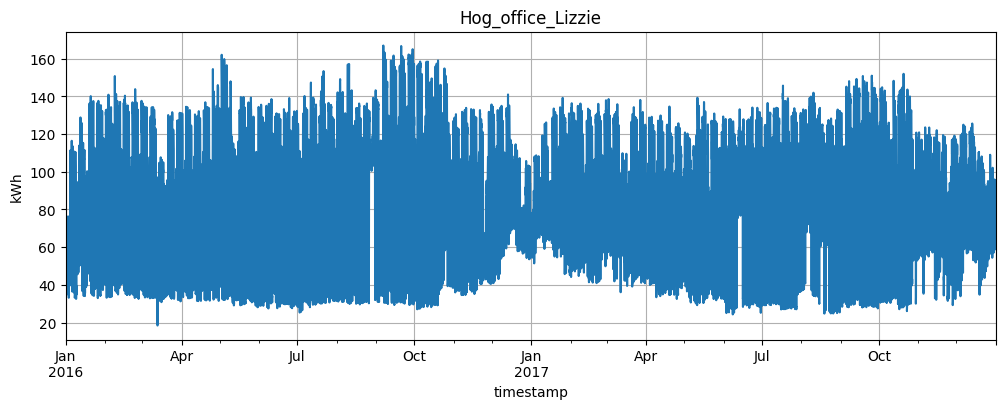

In [ ]:
bid = shortlist[0]
elec[bid].plot(title=bid)
plt.ylabel("kWh")
plt.show()

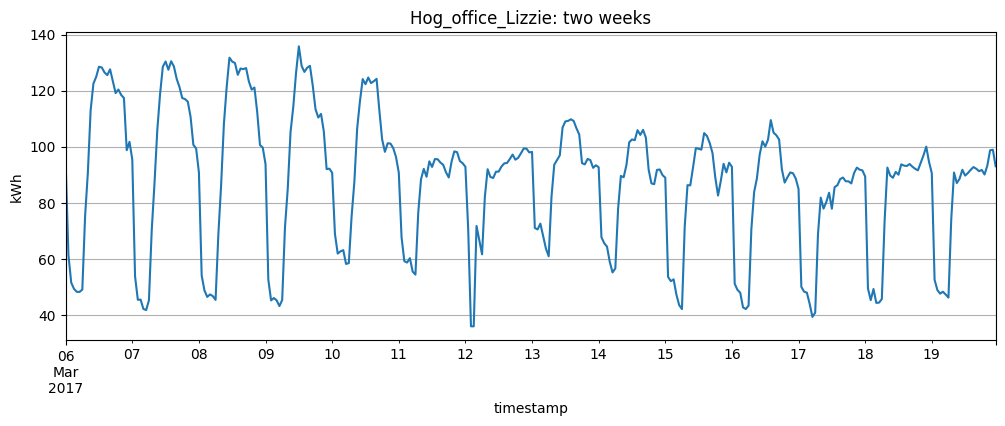

In [ ]:
elec[bid].loc["2017-03-06":"2017-03-19"].plot(title=f"{bid}: two weeks")
plt.ylabel("kWh")
plt.show()

In [ ]:
WX = ["airTemperature", "dewTemperature", "windSpeed"]

def load_building(bid):
    site = meta.loc[meta["building_id"] == bid, "site_id"].iloc[0]
    df = elec[[bid]].rename(columns={bid: "kwh"})
    w = weather[weather["site_id"] == site].set_index("timestamp")[WX]
    w = w[~w.index.duplicated()]
    return df.join(w)

bid = shortlist[0]
raw = load_building(bid)
raw.head()

,kwh,airTemperature,dewTemperature,windSpeed
timestamp,,,,
2016-01-01 00:00:00,42.335,-7.2,-10.6,5.7
2016-01-01 01:00:00,42.335,-6.7,-10.0,4.1
2016-01-01 02:00:00,41.689,-6.7,-9.4,2.6
2016-01-01 03:00:00,45.414,-6.7,-9.4,3.6
2016-01-01 04:00:00,44.866,-8.3,-11.7,6.7


rows: 17544
missing values per column:
kwh               0
airTemperature    4
dewTemperature    4
windSpeed         4
dtype: int64
zeros in kwh: 0
median / max kwh: 97.87899999999999 / 166.928


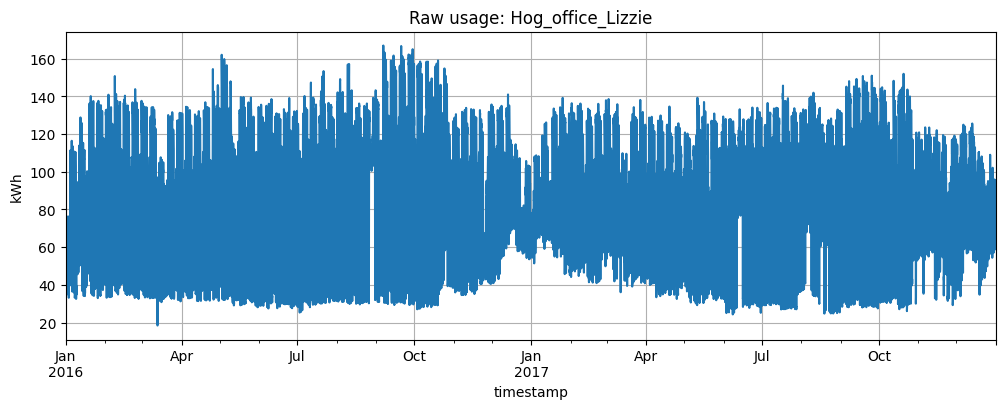

In [ ]:
print("rows:", len(raw))
print("missing values per column:")
print(raw.isna().sum())
print("zeros in kwh:", (raw["kwh"] == 0).sum())
print("median / max kwh:", raw["kwh"].median(), "/", raw["kwh"].max())

raw["kwh"].plot(title=f"Raw usage: {bid}")
plt.ylabel("kWh")
plt.show()

In [ ]:
s = raw["kwh"]
grp = (s != s.shift()).cumsum()
run = s.groupby(grp).transform("size")
print("hours inside flat runs of 24+:", (run >= 24).sum())
print("longest flat run (hours):", run.max())

hours inside flat runs of 24+: 0
longest flat run (hours): 9


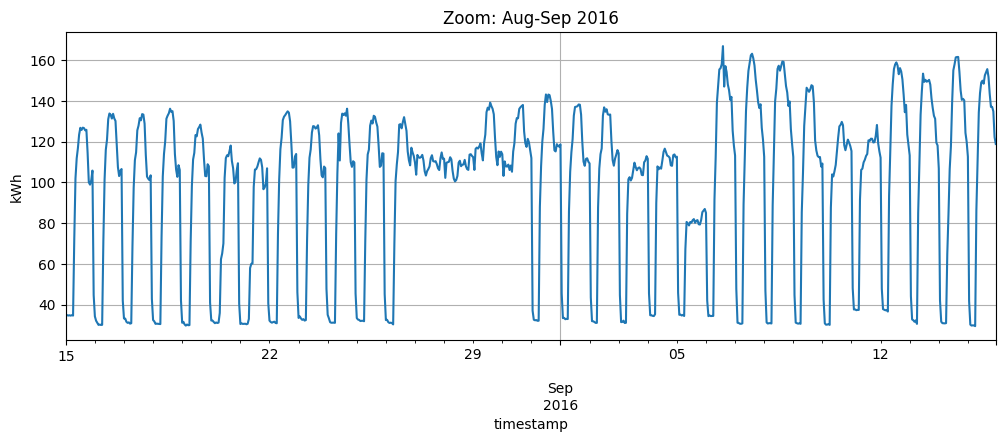

In [ ]:
raw["kwh"].loc["2016-08-15":"2016-09-15"].plot(title="Zoom: Aug-Sep 2016")
plt.ylabel("kWh")
plt.show()

In [ ]:
def mask_flat(s, min_len=24):
    """Set stretches where the value never changes for 24+ hours to NaN (stuck meter)."""
    grp = (s != s.shift()).cumsum()
    run_len = s.groupby(grp).transform("size")
    return s.mask((run_len >= min_len) & s.notna())

def fill_short_gaps(s, max_gap=6):
    """Fill only gaps of 6 hours or fewer. Longer gaps stay empty."""
    isna = s.isna()
    grp = (isna != isna.shift()).cumsum()
    gap_len = isna.groupby(grp).transform("sum")
    filled = s.interpolate(limit_area="inside")
    return s.where(~(isna & (gap_len <= max_gap)), filled)

def clean(df):
    df = df.copy()
    df.loc[df["kwh"] == 0, "kwh"] = np.nan                              # broken meter
    df["kwh"] = mask_flat(df["kwh"])                                    # stuck meter
    df.loc[df["kwh"] > 4 * df["kwh"].quantile(0.99), "kwh"] = np.nan    # absurd spikes
    for c in ["kwh"] + WX:
        df[c] = fill_short_gaps(df[c])                                  # patch short gaps
    return df

missing kwh before: 0 | after: 0
missing weather after:
airTemperature    0
dewTemperature    0
windSpeed         0
dtype: int64


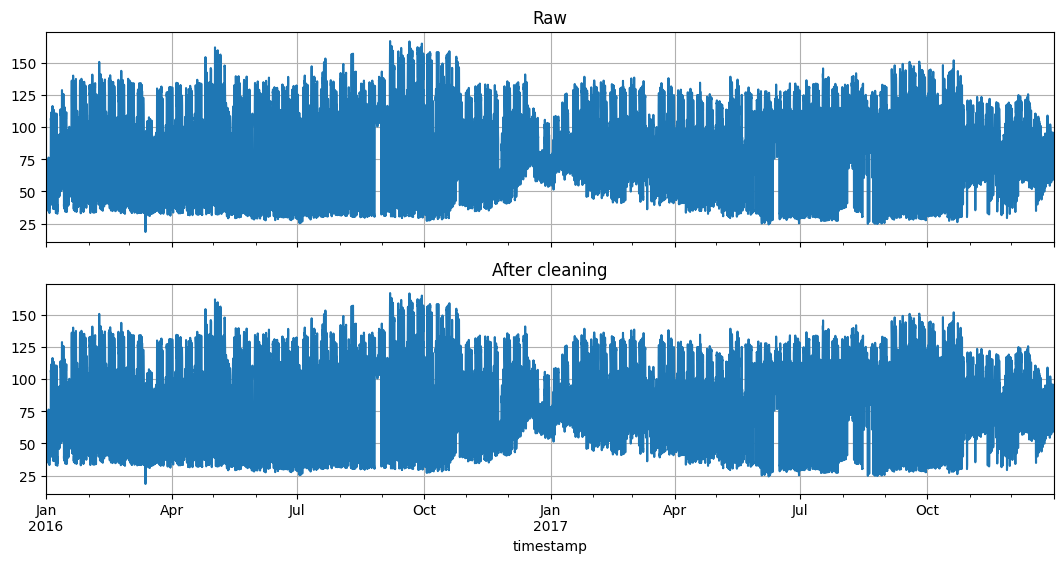

In [ ]:
cleaned = clean(raw)

print("missing kwh before:", raw["kwh"].isna().sum(), "| after:", cleaned["kwh"].isna().sum())
print("missing weather after:")
print(cleaned[WX].isna().sum())

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
raw["kwh"].plot(ax=ax[0], title="Raw")
cleaned["kwh"].plot(ax=ax[1], title="After cleaning")
plt.show()

In [ ]:
rows = []
for b in shortlist:
    r = load_building(b)
    c = clean(r)
    rows.append({"building": b,
                 "missing_before": int(r["kwh"].isna().sum()),
                 "zeros": int((r["kwh"] == 0).sum()),
                 "missing_after": int(c["kwh"].isna().sum())})

pd.DataFrame(rows)

,building,missing_before,zeros,missing_after
0,Hog_office_Lizzie,0,0,0
1,Hog_office_Sydney,0,0,0
2,Hog_office_Sherrie,0,0,0
3,Fox_office_Clayton,2,0,0
4,Fox_office_Karima,2,0,0
5,Fox_office_Edythe,2,0,0
6,Rat_office_Colby,4,0,0
7,Rat_office_Jamal,4,0,0
8,Peacock_office_Burl,9,0,7
9,Peacock_office_Annie,9,0,7


In [ ]:
US_HOL = holidays.US(years=[2016, 2017])

def make_features(df):
    df = df.copy()

    # --- Time clues ---
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.dayofweek          # 0 = Monday ... 6 = Sunday
    df["month"] = df.index.month
    df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)
    df["is_holiday"] = [int(d in US_HOL) for d in df.index.date]

    # --- Cyclical encoding (so 11pm and midnight count as close) ---
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

        # --- Memory clues ---
    df["lag_24"] = df["kwh"].shift(24)       # same hour yesterday
    df["lag_168"] = df["kwh"].shift(168)     # same hour last week
    df["lag_336"] = df["kwh"].shift(336)     # same hour 2 weeks ago
    df["lag_504"] = df["kwh"].shift(504)     # same hour 3 weeks ago

    # --- Rolling historical patterns ---
    df["roll_24_mean"] = (
        df["kwh"].shift(24).rolling(24).mean()
    )

    df["roll_168_mean"] = (
        df["kwh"].shift(24).rolling(168).mean()
    )

    return df.dropna()

FEATURES = [
    "hour_sin","hour_cos","month_sin","month_cos","dayofweek","is_weekend","is_holiday",

    "lag_24", "lag_168","lag_336","lag_504",

    "roll_24_mean","roll_168_mean"
] + WX

def build(bid):
    return make_features(clean(load_building(bid)))

In [ ]:
bid = shortlist[0]
df = build(bid)

print("rows before:", len(clean(load_building(bid))), "| rows after dropna:", len(df))
print("any NaN left:", df[FEATURES].isna().any().any())
df[["kwh", "lag_24", "lag_168", "roll_24_mean", "hour", "dayofweek", "is_holiday"]].head(8)

rows before: 17544 | rows after dropna: 17040
any NaN left: False


,kwh,lag_24,lag_168,roll_24_mean,hour,dayofweek,is_holiday
timestamp,,,,,,,
2016-01-22 00:00:00,42.914,41.040,35.271,96.204667,0,4,0
2016-01-22 01:00:00,37.928,39.828,34.729,96.099958,1,4,0
2016-01-22 02:00:00,34.490,36.416,34.133,95.843583,2,4,0
2016-01-22 03:00:00,35.060,39.824,38.267,95.693833,3,4,0
2016-01-22 04:00:00,35.004,40.474,35.408,95.623333,4,4,0
2016-01-22 05:00:00,38.798,35.391,38.141,95.162708,5,4,0
2016-01-22 06:00:00,34.876,40.368,37.132,94.974708,6,4,0
2016-01-22 07:00:00,55.791,56.248,53.936,94.892417,7,4,0


In [ ]:
c = clean(load_building(bid))
t = df.index[500]                          # any timestamp
print("time:", t)
print("lag_24 in df       :", df.loc[t, "lag_24"])
print("kwh 24h earlier    :", c.loc[t - pd.Timedelta(hours=24), "kwh"])
print("lag_168 in df      :", df.loc[t, "lag_168"])
print("kwh 168h earlier   :", c.loc[t - pd.Timedelta(hours=168), "kwh"])

time: 2016-02-11 20:00:00
lag_24 in df       : 122.433
kwh 24h earlier    : 122.433
lag_168 in df      : 121.217
kwh 168h earlier   : 121.217


In [ ]:
df.loc[df["is_holiday"] == 1, "kwh"].groupby(df.index.date[df["is_holiday"] == 1]).mean().head(10)

,kwh
2016-02-15,95.236542
2016-05-30,56.134167
2016-07-04,58.503625
2016-09-05,71.012083
2016-10-10,105.350375
2016-11-11,90.171167
2016-11-24,58.003500
2016-12-25,70.631750
2016-12-26,71.459125
2017-01-01,67.438208


In [ ]:
def split(df, cutoff="2017-01-01"):
    return df[df.index < cutoff], df[df.index >= cutoff]

def evaluate(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    return {"MAE": float(mae),
            "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAPE": float(np.mean(np.abs((y_true - y_pred) / y_true)) * 100),
            "nMAE %": float(mae / y_true.mean() * 100)}

In [ ]:
df = build(shortlist[0])
train, test = split(df)

print("train rows:", len(train), "| test rows:", len(test))
print("train ends :", train.index.max())
print("test starts:", test.index.min())

train rows: 8280 | test rows: 8760
train ends : 2016-12-31 23:00:00
test starts: 2017-01-01 00:00:00


In [ ]:
base = evaluate(test["kwh"], test["lag_168"])
print({k: round(v, 2) for k, v in base.items()})

{'MAE': 8.24, 'RMSE': 13.35, 'MAPE': 10.92, 'nMAE %': 8.98}


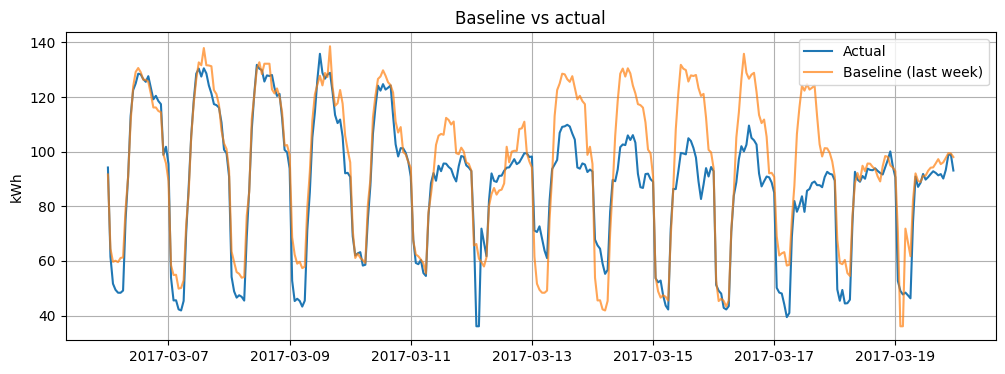

In [ ]:
w = slice("2017-03-06", "2017-03-19")
plt.plot(test["kwh"].loc[w], label="Actual")
plt.plot(test["lag_168"].loc[w], label="Baseline (last week)", alpha=0.7)
plt.legend(); plt.ylabel("kWh"); plt.title("Baseline vs actual")
plt.show()

In [ ]:
from xgboost import XGBRegressor

model = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=42)
model.fit(train[FEATURES], train["kwh"])

pred = model.predict(test[FEATURES])
xgb_score = evaluate(test["kwh"], pred)
print({k: round(v, 2) for k, v in xgb_score.items()})

{'MAE': 5.71, 'RMSE': 8.31, 'MAPE': 7.41, 'nMAE %': 6.22}


In [ ]:
print("Baseline:", {k: round(v, 2) for k, v in base.items()})
print("XGBoost :", {k: round(v, 2) for k, v in xgb_score.items()})
improvement = (1 - xgb_score["MAE"] / base["MAE"]) * 100
print(f"MAE improvement over baseline: {improvement:.1f}%")

Baseline: {'MAE': 8.24, 'RMSE': 13.35, 'MAPE': 10.92, 'nMAE %': 8.98}
XGBoost : {'MAE': 5.71, 'RMSE': 8.31, 'MAPE': 7.41, 'nMAE %': 6.22}
MAE improvement over baseline: 30.8%


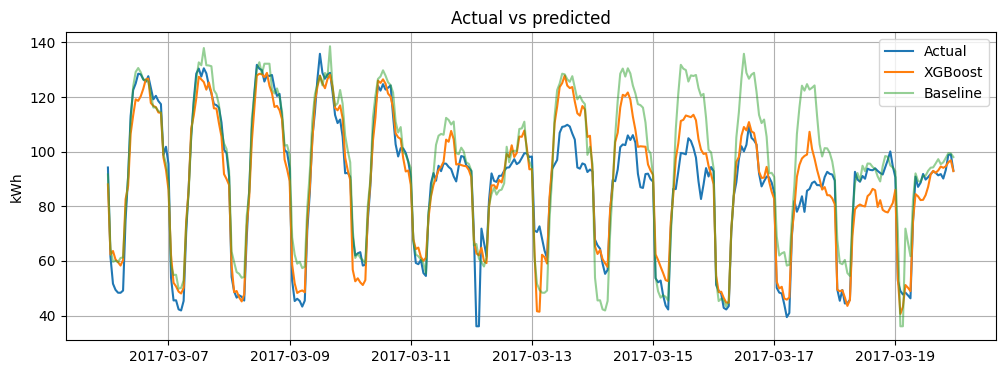

In [ ]:
w = slice("2017-03-06", "2017-03-19")
plt.plot(test["kwh"].loc[w], label="Actual")
plt.plot(pd.Series(pred, index=test.index).loc[w], label="XGBoost")
plt.plot(test["lag_168"].loc[w], label="Baseline", alpha=0.5)
plt.legend(); plt.ylabel("kWh"); plt.title("Actual vs predicted")
plt.show()

In [ ]:
DATA = {}

def get(bid):
    if bid not in DATA:
        DATA[bid] = build(bid)
    return DATA[bid]

In [ ]:
MIN_TRAIN, MIN_TEST = 4000, 4000
rows, store = [], {}

for bid in shortlist:
    d = get(bid)
    tr, te = split(d)
    if len(tr) < MIN_TRAIN or len(te) < MIN_TEST:
        print(f"skip {bid}: train={len(tr)}, test={len(te)} rows (too little usable data)")
        continue

    m = XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6,
                     subsample=0.8, colsample_bytree=0.8, random_state=42)
    m.fit(tr[FEATURES], tr["kwh"])
    p = m.predict(te[FEATURES])

    b = evaluate(te["kwh"], te["lag_168"])
    x = evaluate(te["kwh"], p)

    rows.append({"building": bid,
                 "base_MAE": b["MAE"], "xgb_MAE": x["MAE"],
                 "base_nMAE %": b["nMAE %"], "xgb_nMAE %": x["nMAE %"],
                 "improvement %": (1 - x["MAE"] / b["MAE"]) * 100})
    store[bid] = {"model": m, "test": te.assign(pred=p)}
    print(f"done {bid}: improvement {rows[-1]['improvement %']:.1f}%")

res = pd.DataFrame(rows).set_index("building")
res.round(2)

done Hog_office_Lizzie: improvement 30.8%
done Hog_office_Sydney: improvement 26.0%
done Hog_office_Sherrie: improvement 33.5%
done Fox_office_Clayton: improvement 26.3%
done Fox_office_Karima: improvement 5.3%
done Fox_office_Edythe: improvement 19.0%
done Rat_office_Colby: improvement 32.3%
done Rat_office_Jamal: improvement -61.4%
done Peacock_office_Burl: improvement -17.4%
done Peacock_office_Annie: improvement 38.2%
done Peacock_office_Effie: improvement 32.3%
done Rat_office_Loyd: improvement 27.8%


,base_MAE,xgb_MAE,base_nMAE %,xgb_nMAE %,improvement %
building,,,,,
Hog_office_Lizzie,8.24,5.71,8.98,6.22,30.76
Hog_office_Sydney,7.03,5.20,5.45,4.03,25.97
Hog_office_Sherrie,6.21,4.13,15.37,10.22,33.47
Fox_office_Clayton,9.93,7.32,11.41,8.41,26.30
Fox_office_Karima,7.91,7.49,11.21,10.61,5.32
Fox_office_Edythe,8.43,6.83,7.60,6.16,19.02
Rat_office_Colby,284.86,192.88,12.90,8.73,32.29
Rat_office_Jamal,121.63,196.31,15.20,24.54,-61.40
Peacock_office_Burl,4.21,4.94,7.37,8.65,-17.37


Buildings evaluated: 12
Average improvement: 16.1% (std 28.8%)
XGBoost beat baseline in 10 of 12 buildings


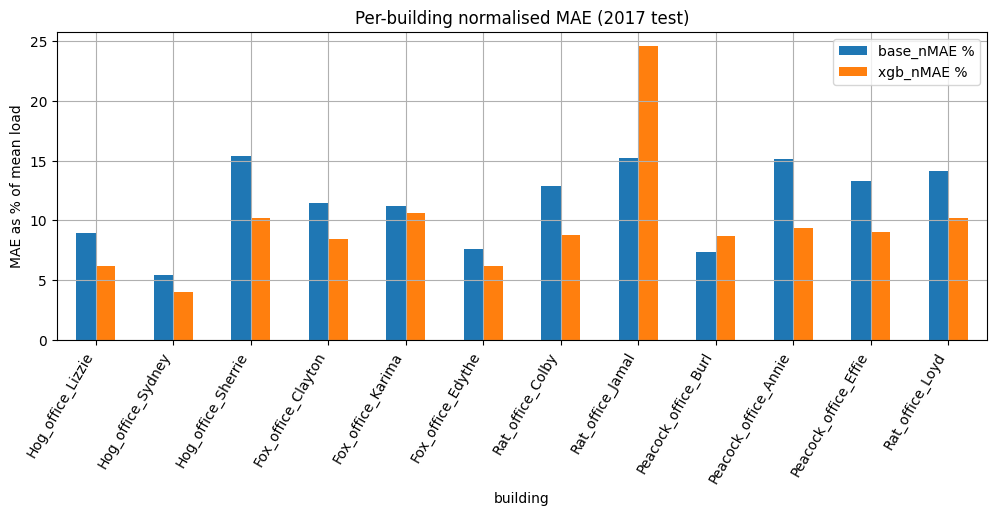

In [ ]:
print(f"Buildings evaluated: {len(res)}")
print(f"Average improvement: {res['improvement %'].mean():.1f}% (std {res['improvement %'].std():.1f}%)")
print(f"XGBoost beat baseline in {(res['improvement %'] > 0).sum()} of {len(res)} buildings")

res[["base_nMAE %", "xgb_nMAE %"]].plot(kind="bar", title="Per-building normalised MAE (2017 test)")
plt.ylabel("MAE as % of mean load")
plt.xticks(rotation=60, ha="right")
plt.show()


Rat_office_Jamal
  kwh stats: {'mean': 930.22, 'std': 505.34, 'min': 70.66, 'max': 2939.15}
  train rows: 8280 | test rows: 8760


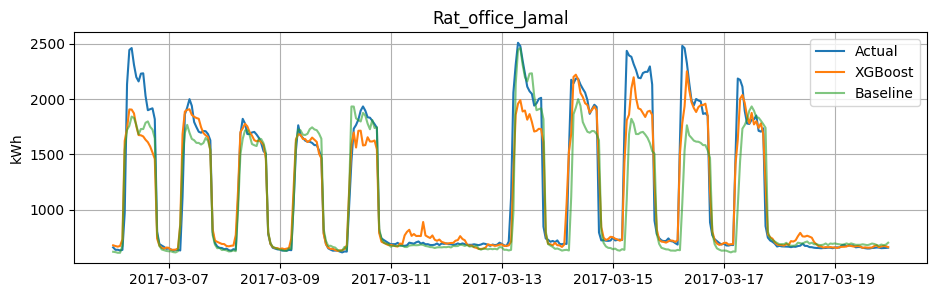


Peacock_office_Burl
  kwh stats: {'mean': 59.74, 'std': 8.67, 'min': 29.03, 'max': 95.18}
  train rows: 8092 | test rows: 8753


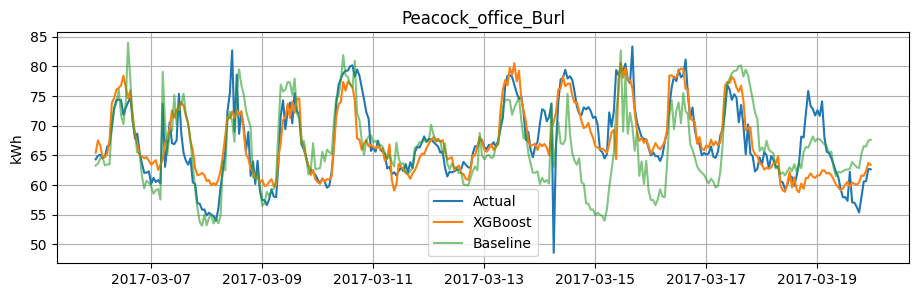

In [ ]:
for bid in ["Rat_office_Jamal", "Peacock_office_Burl"]:
    d = get(bid)
    print(f"\n{bid}")
    print("  kwh stats:", d["kwh"].describe()[["mean","std","min","max"]].round(2).to_dict())
    tr, te = split(d)
    print("  train rows:", len(tr), "| test rows:", len(te))

    w = slice("2017-03-06", "2017-03-19")
    plt.figure(figsize=(11,3))
    plt.plot(store[bid]["test"]["kwh"].loc[w], label="Actual")
    plt.plot(store[bid]["test"]["pred"].loc[w], label="XGBoost")
    plt.plot(te["lag_168"].loc[w], label="Baseline", alpha=0.6)
    plt.legend(); plt.title(bid); plt.ylabel("kWh")
    plt.show()

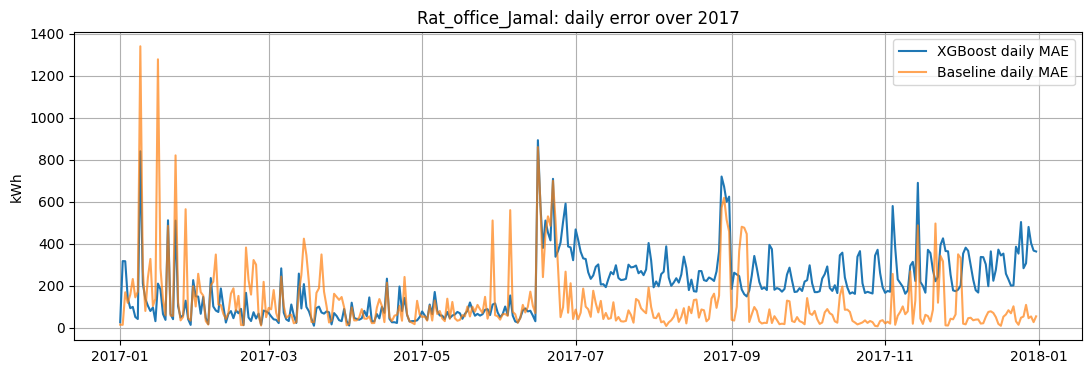

Worst 5 days for XGBoost:
timestamp
2017-06-16    893.213016
2017-01-09    840.272504
2017-08-28    719.895515
2017-06-22    709.010867
2017-11-14    689.841144
dtype: float64


In [ ]:
te = store["Rat_office_Jamal"]["test"]
daily_err_xgb = (te["kwh"] - te["pred"]).abs().resample("D").mean()
daily_err_base = (te["kwh"] - te["lag_168"]).abs().resample("D").mean()

plt.figure(figsize=(13,4))
plt.plot(daily_err_xgb, label="XGBoost daily MAE")
plt.plot(daily_err_base, label="Baseline daily MAE", alpha=0.7)
plt.legend(); plt.title("Rat_office_Jamal: daily error over 2017")
plt.ylabel("kWh")
plt.show()

print("Worst 5 days for XGBoost:")
print(daily_err_xgb.sort_values(ascending=False).head(5))

In [ ]:
te = store["Rat_office_Jamal"]["test"]
h1 = te.loc[:"2017-06-01", "kwh"].mean()
h2 = te.loc["2017-06-01":, "kwh"].mean()
print(f"Avg kwh Jan-May 2017: {h1:.1f}")
print(f"Avg kwh Jun-Dec 2017: {h2:.1f}")

train_avg = get("Rat_office_Jamal").loc[:"2017-01-01","kwh"].mean()
print(f"Avg kwh during 2016 (training): {train_avg:.1f}")

Avg kwh Jan-May 2017: 1054.9
Avg kwh Jun-Dec 2017: 620.5
Avg kwh during 2016 (training): 1066.6


In [ ]:
FOLDS = [("2017-01-01", "2017-04-01"), ("2017-04-01", "2017-07-01"),
         ("2017-07-01", "2017-10-01"), ("2017-10-01", "2018-01-01")]

wf = []
for bid in store:
    d = get(bid)
    for i, (s, e_) in enumerate(FOLDS, 1):
        tr, te = d[d.index < s], d[(d.index >= s) & (d.index < e_)]
        if len(tr) < MIN_TRAIN or len(te) < 200:
            continue
        m = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8, random_state=42)
        m.fit(tr[FEATURES], tr["kwh"])
        p = m.predict(te[FEATURES])
        b = evaluate(te["kwh"], te["lag_168"])
        x = evaluate(te["kwh"], p)
        wf.append({"building": bid, "fold": f"Q{i} 2017",
                   "base_nMAE %": b["nMAE %"], "xgb_nMAE %": x["nMAE %"],
                   "improvement %": (1 - x["MAE"] / b["MAE"]) * 100})

wf = pd.DataFrame(wf)
wf.groupby("fold")[["base_nMAE %", "xgb_nMAE %", "improvement %"]].mean().round(2)

,base_nMAE %,xgb_nMAE %,improvement %
fold,,,
Q1 2017,12.03,8.06,32.26
Q2 2017,11.44,8.33,26.22
Q3 2017,10.54,8.22,13.04
Q4 2017,12.05,8.99,24.07


In [ ]:
wf[wf["building"] == "Rat_office_Jamal"]

,building,fold,base_nMAE %,xgb_nMAE %,improvement %
28,Rat_office_Jamal,Q1 2017,15.846269,9.387504,40.758899
29,Rat_office_Jamal,Q2 2017,14.279076,14.911229,-4.427135
30,Rat_office_Jamal,Q3 2017,16.687864,14.346688,14.029212
31,Rat_office_Jamal,Q4 2017,13.740220,17.251736,-25.556480


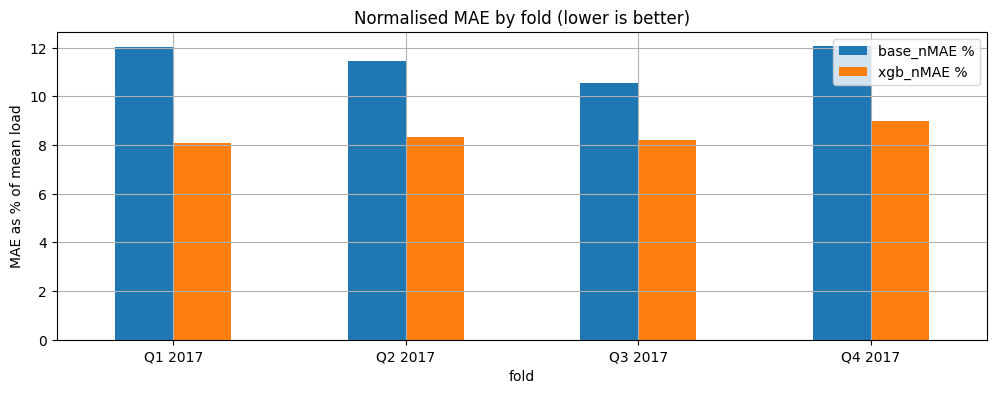

Overall improvement across folds/buildings: 23.9% (std 26.2%)


In [ ]:
piv = wf.pivot_table(index="fold", values=["base_nMAE %", "xgb_nMAE %"], aggfunc="mean")
piv.plot(kind="bar", title="Normalised MAE by fold (lower is better)")
plt.ylabel("MAE as % of mean load"); plt.xticks(rotation=0)
plt.show()

print(f"Overall improvement across folds/buildings: {wf['improvement %'].mean():.1f}% (std {wf['improvement %'].std():.1f}%)")

In [ ]:
d = get("Rat_office_Jamal")
periods = {
    "2016 (orig. train)": d.loc[:"2017-01-01", "kwh"],
    "Q1 2017": d.loc["2017-01-01":"2017-04-01", "kwh"],
    "Q2 2017": d.loc["2017-04-01":"2017-07-01", "kwh"],
    "Q3 2017": d.loc["2017-07-01":"2017-10-01", "kwh"],
    "Q4 2017": d.loc["2017-10-01":"2018-01-01", "kwh"],
}
for name, s in periods.items():
    print(f"{name:20s} mean={s.mean():7.1f}  std={s.std():6.1f}")

2016 (orig. train)   mean= 1066.6  std= 484.8
Q1 2017              mean= 1125.3  std= 617.1
Q2 2017              mean=  888.1  std= 431.2
Q3 2017              mean=  621.4  std= 312.6
Q4 2017              mean=  561.5  std= 302.4


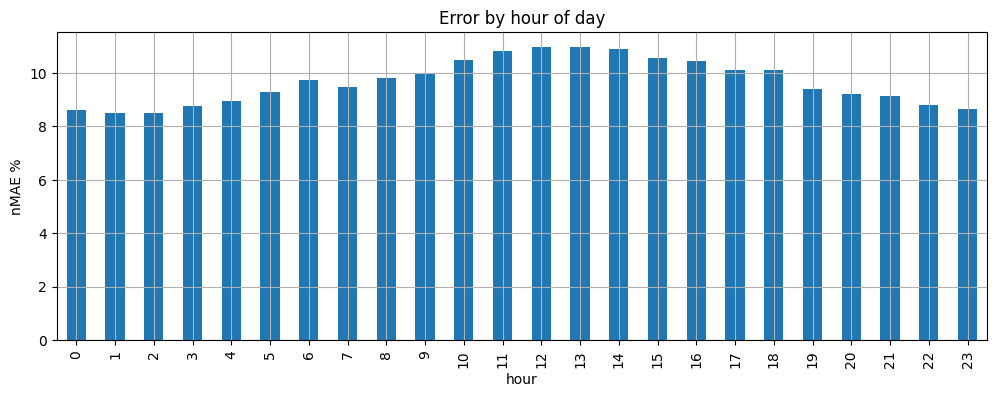

By day type (nMAE %):
is_weekend
Weekday    10.02
Weekend     8.83
Name: norm_err, dtype: float64

By holiday (nMAE %):
is_holiday
Normal day     9.47
Holiday       15.78
Name: norm_err, dtype: float64


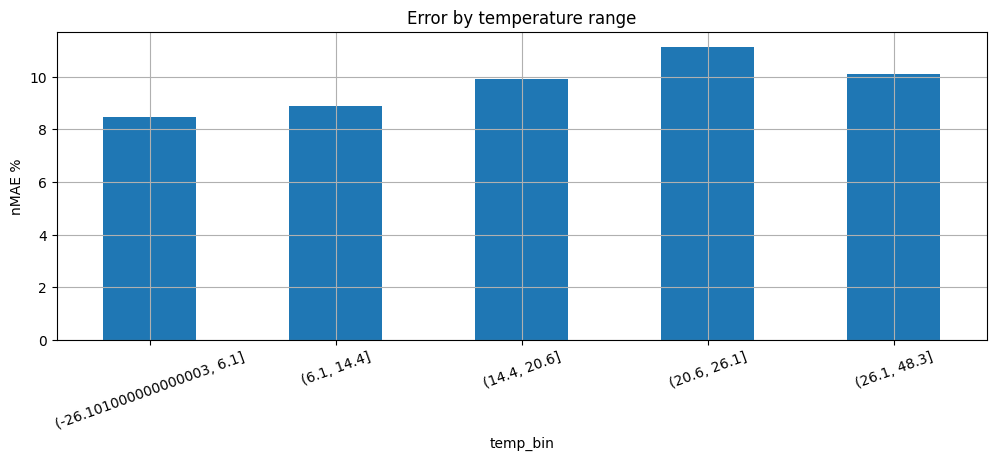

In [ ]:
allp = []
for bid, d in store.items():
    t = d["test"].copy()
    t["building"] = bid
    t["norm_err"] = (t["kwh"] - t["pred"]).abs() / t["kwh"].mean() * 100
    allp.append(t)
allp = pd.concat(allp)

allp.groupby("hour")["norm_err"].mean().plot(kind="bar", title="Error by hour of day")
plt.ylabel("nMAE %"); plt.show()

print("By day type (nMAE %):")
print(allp.groupby("is_weekend")["norm_err"].mean().rename({0: "Weekday", 1: "Weekend"}).round(2))

print("\nBy holiday (nMAE %):")
print(allp.groupby("is_holiday")["norm_err"].mean().rename({0: "Normal day", 1: "Holiday"}).round(2))

allp["temp_bin"] = pd.qcut(allp["airTemperature"], 5)
allp.groupby("temp_bin")["norm_err"].mean().plot(kind="bar", title="Error by temperature range")
plt.ylabel("nMAE %"); plt.xticks(rotation=20); plt.show()

Worst days: {datetime.date(2017, 6, 12): 31.4, datetime.date(2017, 6, 14): 28.4, datetime.date(2017, 8, 16): 21.7}


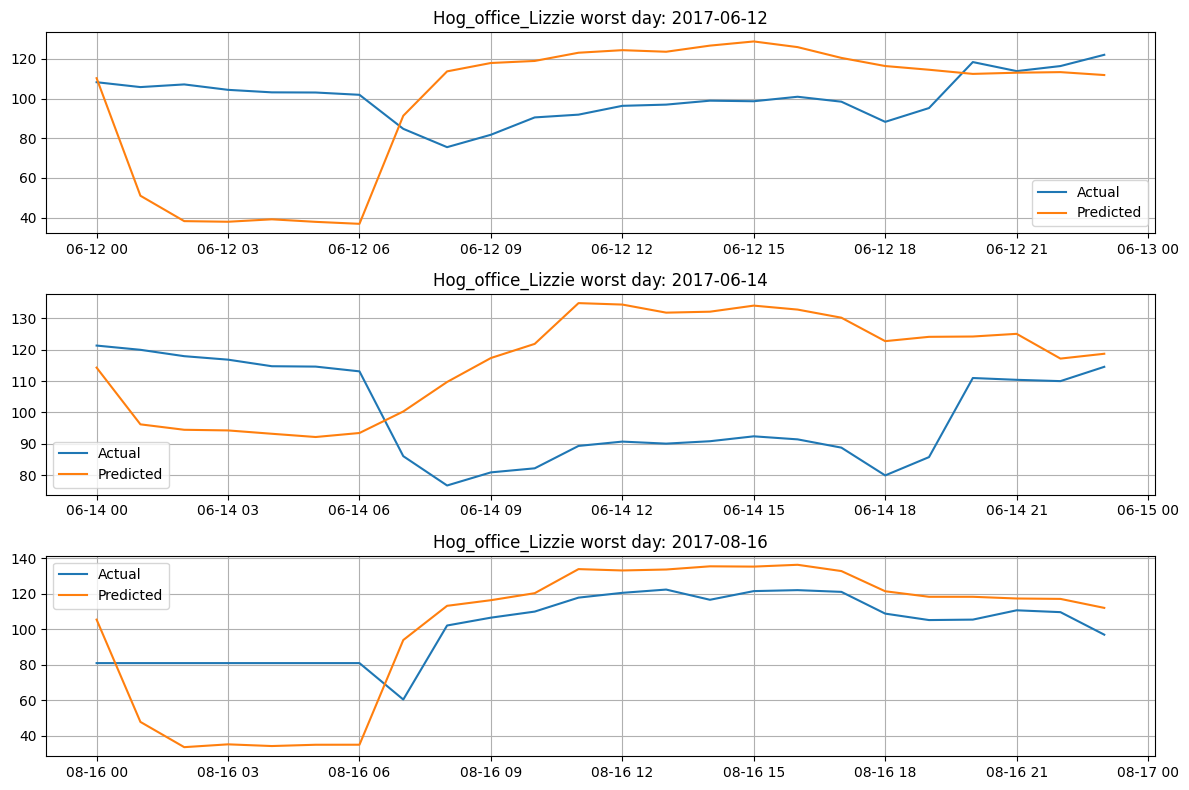

In [ ]:
b0 = list(store)[0]
t = store[b0]["test"]
daily = (t["kwh"] - t["pred"]).abs().groupby(t.index.date).mean().sort_values(ascending=False)
print("Worst days:", daily.head(3).round(1).to_dict())

fig, axes = plt.subplots(3, 1, figsize=(12, 8))
for ax, day in zip(axes, daily.head(3).index):
    dd = t.loc[str(day)]
    ax.plot(dd["kwh"], label="Actual"); ax.plot(dd["pred"], label="Predicted")
    ax.set_title(f"{b0} worst day: {day}"); ax.legend()
plt.tight_layout(); plt.show()

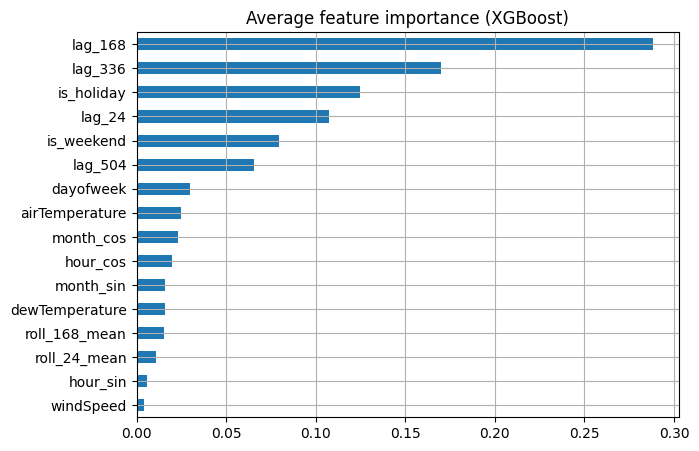

,0
lag_168,0.288
lag_336,0.170
is_holiday,0.125
lag_24,0.107
is_weekend,0.080
lag_504,0.065
dayofweek,0.030
airTemperature,0.025
month_cos,0.023
hour_cos,0.020


In [ ]:
imp = pd.DataFrame({b: pd.Series(d["model"].feature_importances_, index=FEATURES) for b, d in store.items()})
imp.mean(axis=1).sort_values().plot(kind="barh", figsize=(7, 5), title="Average feature importance (XGBoost)")
plt.show()
imp.mean(axis=1).sort_values(ascending=False).round(3)

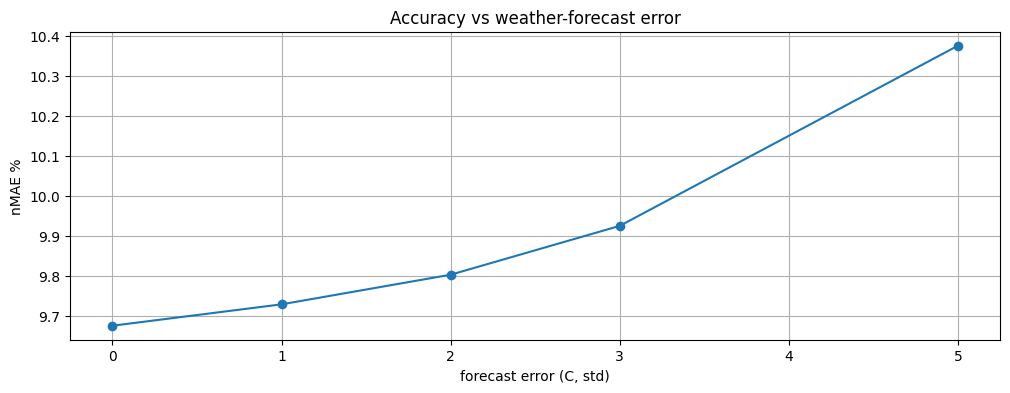

,avg nMAE %
"forecast error (C, std)",
0,9.68
1,9.73
2,9.80
3,9.93
5,10.38


In [ ]:
rng = np.random.default_rng(42)
out = []
for sd in [0, 1, 2, 3, 5]:
    errs = []
    for bid, d in store.items():
        te = d["test"].copy()
        days = te.index.normalize()
        offs = pd.Series(rng.normal(0, sd, days.nunique()), index=days.unique()).reindex(days).values
        te["airTemperature"] += offs
        te["dewTemperature"] += offs
        p = d["model"].predict(te[FEATURES])
        errs.append(mean_absolute_error(te["kwh"], p) / te["kwh"].mean() * 100)
    out.append({"forecast error (C, std)": sd, "avg nMAE %": np.mean(errs)})

noise = pd.DataFrame(out).set_index("forecast error (C, std)")
noise.plot(marker="o", title="Accuracy vs weather-forecast error", legend=False)
plt.ylabel("nMAE %"); plt.show()
noise.round(2)

Hog_office_Lizzie: 71.3% of actual values fall inside the 80% interval (target ~80%)


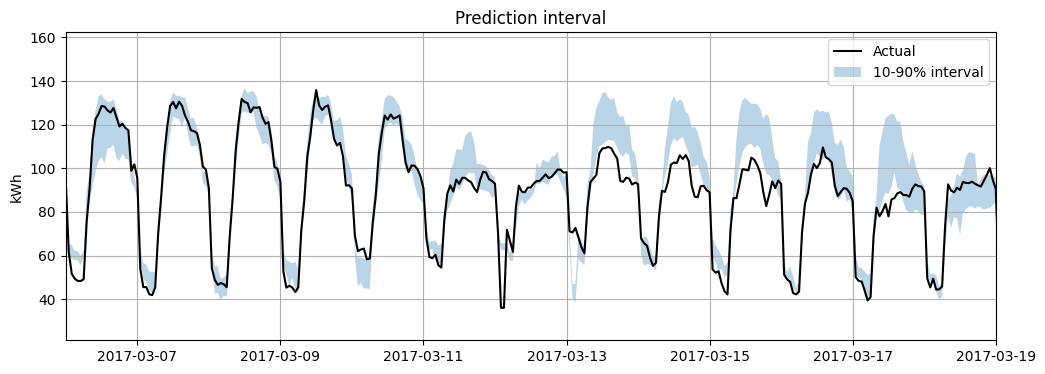

In [ ]:
!pip install -q lightgbm
from lightgbm import LGBMRegressor

b0 = list(store)[0]
tr, te = split(get(b0))

def q_model(alpha):
    return LGBMRegressor(objective="quantile", alpha=alpha, n_estimators=400, learning_rate=0.05,
                         max_depth=6, subsample=0.8, subsample_freq=1, colsample_bytree=0.8,
                         random_state=42, verbose=-1).fit(tr[FEATURES], tr["kwh"])

lo, hi = q_model(0.1).predict(te[FEATURES]), q_model(0.9).predict(te[FEATURES])
coverage = ((te["kwh"] >= lo) & (te["kwh"] <= hi)).mean() * 100
print(f"{b0}: {coverage:.1f}% of actual values fall inside the 80% interval (target ~80%)")

w = slice("2017-03-06", "2017-03-19")
plt.plot(te["kwh"].loc[w], label="Actual", color="black")
plt.fill_between(te.index, lo, hi, alpha=0.3, label="10-90% interval")
plt.xlim(pd.Timestamp("2017-03-06"), pd.Timestamp("2017-03-19"))
plt.legend(); plt.ylabel("kWh"); plt.title("Prediction interval"); plt.show()

In [ ]:
import os, joblib

os.makedirs("export/models", exist_ok=True)

# 1. Save all trained models
for bid, d in store.items():
    d["model"].save_model(f"export/models/{bid}.json")

# 2. Save building IDs
joblib.dump(
    list(store.keys()),
    "export/building_ids.pkl"
)

# 3. Save FULL historical data
full_history = {}

for bid in store:
    raw = clean(load_building(bid))
    full_history[bid] = raw.copy()

joblib.dump(
    full_history,
    "export/full_history.pkl"
)

# 4. Save the exact feature list used during training
joblib.dump(
    FEATURES,
    "export/features.pkl"
)

# 5. Zip everything
!zip -r export.zip export

# 6. Download
from google.colab import files
files.download("export.zip")

updating: export/ (stored 0%)
updating: export/building_ids.pkl (deflated 46%)
updating: export/full_history.pkl (deflated 81%)
updating: export/features.pkl (deflated 31%)
updating: export/models/ (stored 0%)
updating: export/models/Peacock_office_Burl.json (deflated 76%)
updating: export/models/Fox_office_Karima.json (deflated 75%)
updating: export/models/Peacock_office_Effie.json (deflated 76%)
updating: export/models/Hog_office_Sydney.json (deflated 76%)
updating: export/models/Fox_office_Clayton.json (deflated 76%)
updating: export/models/Rat_office_Loyd.json (deflated 76%)
updating: export/models/Rat_office_Jamal.json (deflated 75%)
updating: export/models/Fox_office_Edythe.json (deflated 76%)
updating: export/models/Hog_office_Lizzie.json (deflated 75%)
updating: export/models/Hog_office_Sherrie.json (deflated 76%)
updating: export/models/Peacock_office_Annie.json (deflated 76%)
updating: export/models/Rat_office_Colby.json (deflated 75%)
updating: export/recent_data.pkl (deflat

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>